In [115]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets , transforms
from torch.utils.data import DataLoader

from sklearn.metrics import accuracy_score , confusion_matrix 
import numpy as np
import matplotlib.pyplot as plt


In [116]:
transform = transforms.ToTensor()


train_data = datasets.FashionMNIST(
    root = "data",
    train = True,
    download=True,
    transform=transform
)

In [117]:
test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download=True,
    transform=transform
)

In [118]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [119]:
train_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [120]:
train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

In [121]:
test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

In [122]:

conv1 = nn.Conv2d(1,6,3,1)
conv2 = nn.Conv2d(6,16,3,1)

In [123]:
for i, (X_Train ,y_train) in enumerate(train_data):
    pass

In [124]:
x = X_Train.view(1,1,28,28)

In [125]:
import torch.nn.functional as F
x = F.relu(conv1(x))

In [126]:
x.shape

torch.Size([1, 6, 26, 26])

In [127]:
x = F.max_pool2d(x,2,2) 

In [128]:
x.shape

torch.Size([1, 6, 13, 13])

In [129]:
class FashionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        
        x = torch.flatten(x, 1)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [130]:
model = FashionNetwork()

print(model)

FashionNetwork(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [131]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters() , lr = 0.001)

In [132]:
# Use the GPU when available; otherwise use the CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# CrossEntropyLoss is suitable for the 10 FashionMNIST classes.
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [133]:
epochs = 10
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Read one batch of images and labels at a time.
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Make predictions for this batch.
        outputs = model(images)

        # Compare predictions with the correct labels.
        loss = loss_fn(outputs, labels)

        # Update the model weights.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predictions = outputs.argmax(dim=1)
        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)

    average_loss = running_loss / len(train_loader)
    accuracy = 100 * correct_predictions / total_samples
    train_losses.append(average_loss)
    train_accuracies.append(accuracy)

    print(
        f"Epoch [{epoch + 1}/{epochs}], "
        f"Loss: {average_loss:.4f}, "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch [1/10], Loss: 0.4660, Accuracy: 83.10%
Epoch [2/10], Loss: 0.3028, Accuracy: 88.92%
Epoch [3/10], Loss: 0.2533, Accuracy: 90.65%
Epoch [4/10], Loss: 0.2220, Accuracy: 91.78%
Epoch [5/10], Loss: 0.1939, Accuracy: 92.84%
Epoch [6/10], Loss: 0.1743, Accuracy: 93.57%
Epoch [7/10], Loss: 0.1539, Accuracy: 94.34%
Epoch [8/10], Loss: 0.1346, Accuracy: 94.97%
Epoch [9/10], Loss: 0.1172, Accuracy: 95.61%
Epoch [10/10], Loss: 0.1020, Accuracy: 96.14%


In [134]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    
    for images , labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%") 
        

Test Accuracy: 91.92%


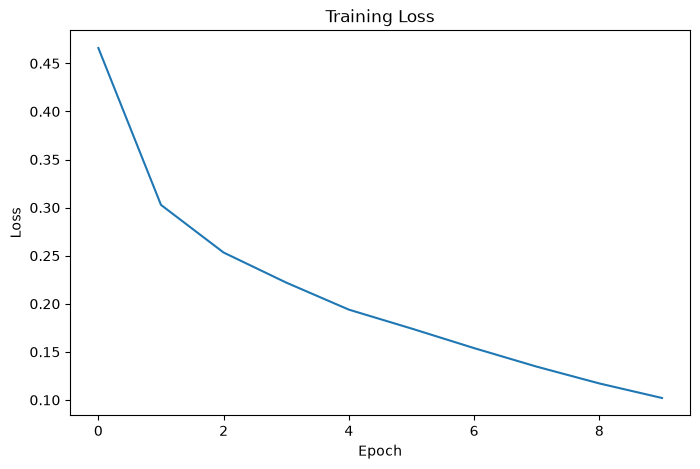

In [135]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

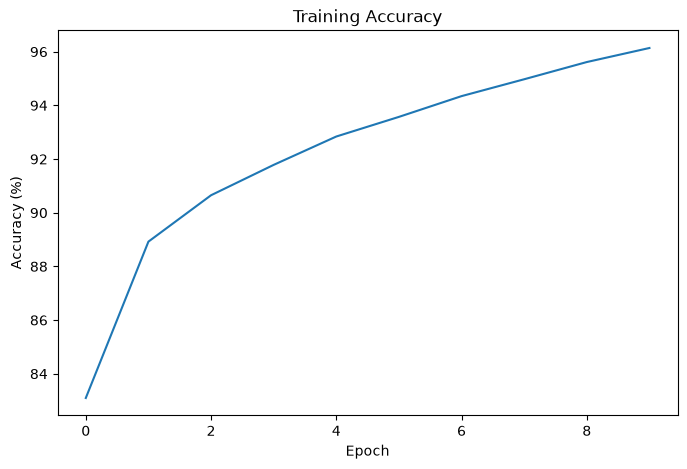

In [136]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy")

plt.show()

In [137]:
torch.save(
    model.state_dict(),
    "fashion_cnn.pth"
)

In [138]:
model = FashionNetwork().to(device)

model.load_state_dict(
    torch.load(
        "fashion_cnn.pth",
        map_location=device
    )
)

model.eval()

FashionNetwork(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)